# Apple Stock Price Prediction using Machine Learning (LSTM)

## Overview & Workflow

This notebook downloads historical Apple (AAPL) stock data for a user-specified period, performs exploratory data analysis and visualizations (price, moving averages, volume, returns, cumulative returns), preprocesses and scales the closing prices, trains an LSTM neural network to forecast closing prices, evaluates performance (RMSE), and visualizes train vs. predicted results on the validation set.

## 1. Install required packages

In [1]:
pip install scikit-learn yfinance neuralprophet pandas matplotlib tensorflow

Note: you may need to restart the kernel to use updated packages.


## 2. Import the necessary libraries

In [2]:
from neuralprophet import NeuralProphet
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


## 3. EDA (Exploratory Data Analysis)

In [3]:
ticker = input("Stock Ticker:") # "AAPL"
start_date = input("Start(YYYY-MM-DD):") # "2020-01-01"
end_date = input("End(YYYY-MM-DD):") # "2026-06-28" - yesterday

In [4]:
stock_data = yf.download(ticker, start=start_date, end=end_date)
stock_data = stock_data.reset_index()
stock_data.columns = stock_data.columns.get_level_values(0)

print(stock_data.head())
stock_data.to_csv("stock_data.csv")

[*********************100%***********************]  1 of 1 completed

Price       Date      Close       High        Low       Open     Volume
0     2020-01-02  72.333878  72.394086  71.091184  71.344054  135480400
1     2020-01-03  71.630653  72.389273  71.406681  71.563221  146322800
2     2020-01-06  72.201401  72.239935  70.503539  70.754006  118387200
3     2020-01-07  71.861847  72.466330  71.642689  72.211049  108872000
4     2020-01-08  73.017845  73.318885  71.565629  71.565629  132079200


In [5]:
stock_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    1629 non-null   datetime64[s]
 1   Close   1629 non-null   float64      
 2   High    1629 non-null   float64      
 3   Low     1629 non-null   float64      
 4   Open    1629 non-null   float64      
 5   Volume  1629 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 76.5 KB


In [6]:
stock_data.isnull().sum()

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 3. Data Visualization

### Stock Price

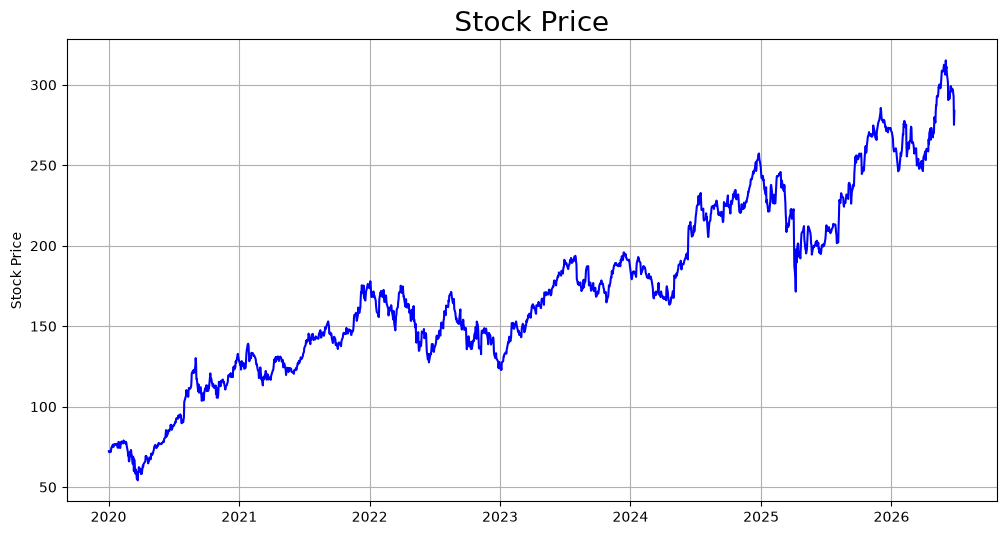

In [7]:
fig, ax = plt.subplots(figsize=(12,6))
plt.title("Stock Price", fontsize="20")
ax.plot(stock_data["Date"], stock_data["Close"], color="Blue")
ax.set_ylabel("Stock Price")
plt.grid()
plt.show()

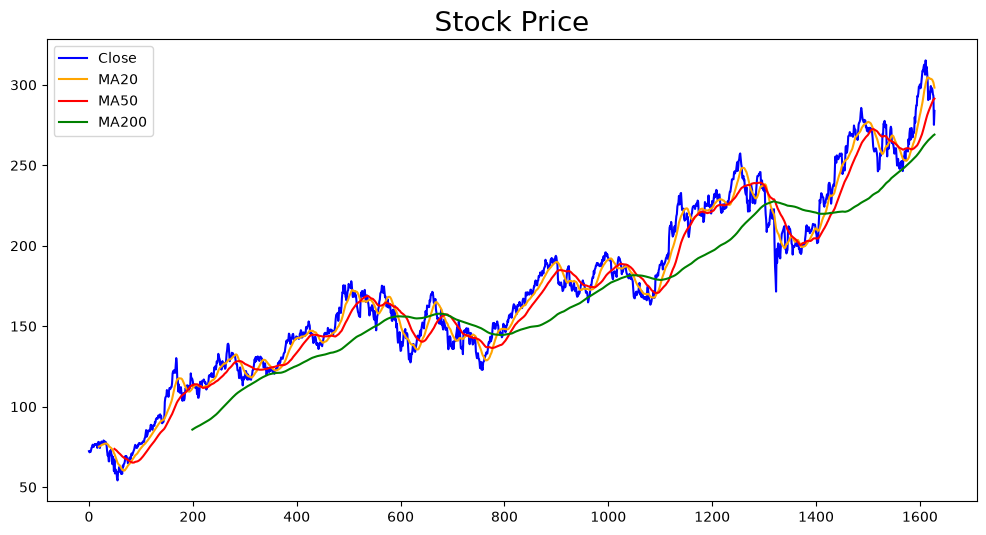

In [8]:
MA20=stock_data.Close.rolling(20).mean()
MA50=stock_data.Close.rolling(50).mean()
MA200=stock_data.Close.rolling(200).mean()
fig, ax = plt.subplots(figsize=(12,6))
plt.title("Stock Price",fontsize= 20)
plt.plot(stock_data.Close, color="Blue", label="Close")
plt.plot(MA20, color = "Orange", label = "MA20")
plt.plot(MA50, color = "Red", label = "MA50")
plt.plot(MA200, color = "green", label = "MA200")
plt.legend()

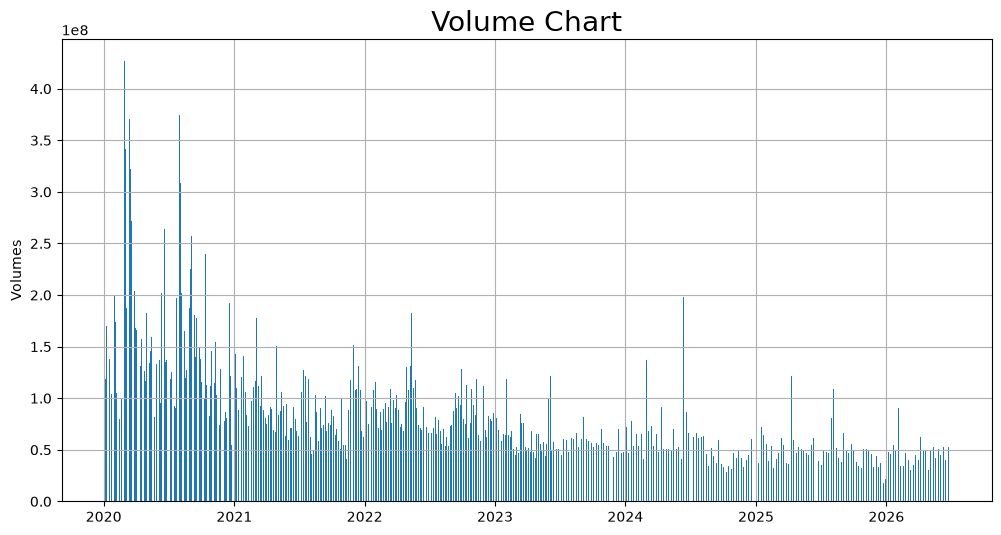

In [9]:
fig, ax = plt.subplots(figsize=(12,6))
plt.title("Volume Chart", fontsize="20")
ax.bar(stock_data["Date"], stock_data["Volume"])
ax.set_ylabel("Volumes")
plt.grid()
plt.show()

### Daily Return

In [10]:
stock_data["Daily Return"] = stock_data["Close"].pct_change(1)
stock_data["Daily Return"]

0            NaN
1      -0.009722
2       0.007968
3      -0.004703
4       0.016086
          ...   
1624   -0.003356
1625   -0.009124
1626   -0.004145
1627   -0.061178
1628    0.031365
Name: Daily Return, Length: 1629, dtype: float64

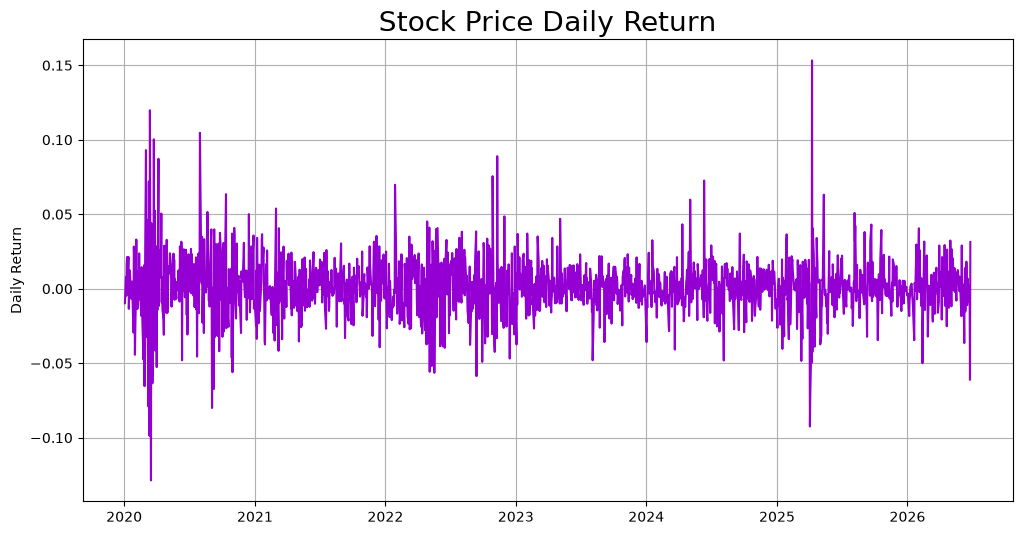

In [11]:
fig, ax = plt.subplots(figsize=(12,6))
plt.title("Stock Price Daily Return",fontsize="20")
ax.plot(stock_data["Date"], stock_data["Daily Return"], color="Darkviolet")
ax.set_ylabel("Daily Return")
plt.grid()
plt.show()

### Distribution of Daily Return (Volatility)

<Axes: >

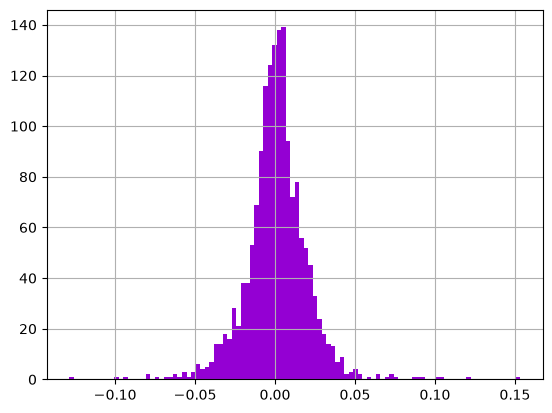

In [12]:
stock_data.iloc[stock_data["Daily Return"].argmax()]
stock_data["Daily Return"].hist(bins=100, color="Darkviolet")

### Cumulative Return

In [13]:
stock_data["Cumulative Return"] = (1+stock_data["Daily Return"]).cumprod() 
stock_data["Cumulative Return"]

0            NaN
1       0.990278
2       0.998169
3       0.993474
4       1.009456
          ...   
1624    4.106098
1625    4.068633
1626    4.051767
1627    3.803888
1628    3.923196
Name: Cumulative Return, Length: 1629, dtype: float64

### Cumulative Return of the stock during the given period

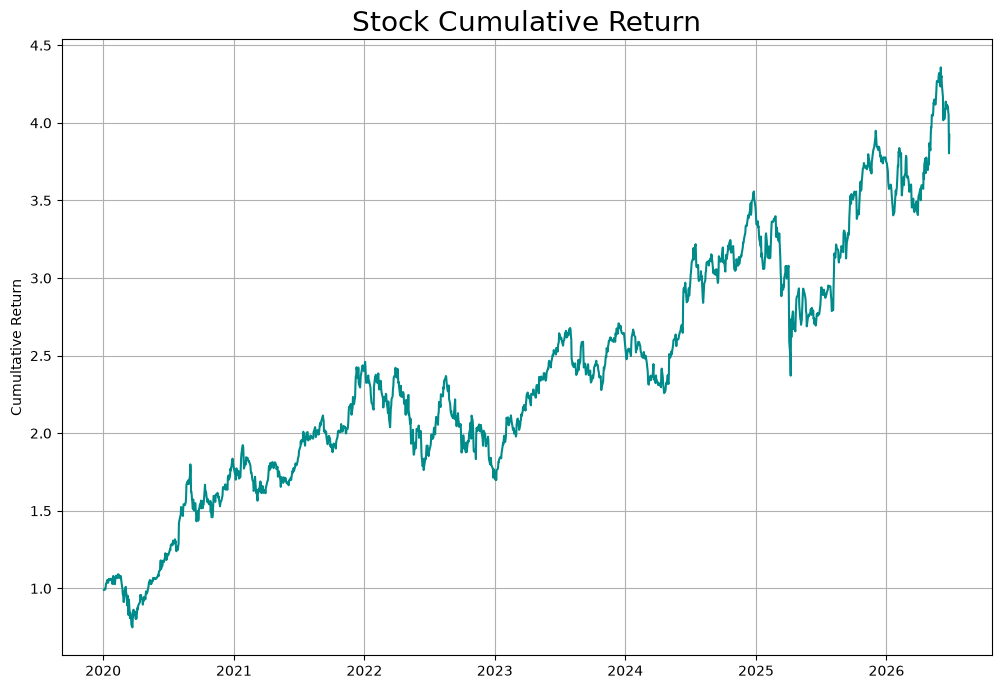

In [14]:
fig, ax = plt.subplots(figsize=(12,8))
plt.title("Stock Cumulative Return",fontsize="20")
ax.plot(stock_data["Date"], stock_data["Cumulative Return"], color="Darkcyan")
ax.set_ylabel("Cumultative Return")
plt.grid()
plt.show()

## 4. Data Preprocessing

### Splitting Data into Training and Validation Sets

In [15]:
stock_data["Date"] = pd.to_datetime(stock_data["Date"])
stock_data.set_index("Date",inplace=True)
Close = stock_data.filter(["Close"])
CloseValue = Close.values
TrainingDataLength = math.ceil(len(CloseValue)*.8)
TrainingDataLength

1304

### Scaling Data

In [16]:
scaler = MinMaxScaler(feature_range=(0,1))
PriceData = scaler.fit_transform(CloseValue)
PriceData
## Customized the function: 
# def Rank(data):
#     feature_range = data.max() - data.min()
#     scaled_data = (data - data.min()) / feature_range
#     return scaled_data
# PriceData = Rank(CloseValue)
# Rank(CloseValue)

array([[0.06960783],
       [0.06691386],
       [0.06910032],
       ...,
       [0.91526073],
       [0.846573  ],
       [0.87963355]])

In [17]:
X_train, Y_train = [],[]
Backcandles = 45
TrainData = PriceData[0:TrainingDataLength] 
for i in range(Backcandles,len(TrainData)):
    X_train.append(TrainData[i-Backcandles:i, 0])
    Y_train.append(TrainData[i,0])
    if i<= Backcandles:
        print("X_train:",X_train,"\nY_train:",Y_train)
X_train,Y_train = np.array(X_train), np.array(Y_train)

X_train: [array([0.06960783, 0.06691386, 0.06910032, 0.06779953, 0.07222803,
       0.07816956, 0.07881525, 0.08493218, 0.08098345, 0.07974717,
       0.08334529, 0.08656523, 0.0845724 , 0.08561493, 0.08702656,
       0.08617762, 0.07754223, 0.08560567, 0.09174092, 0.09130737,
       0.07805879, 0.07727462, 0.08667592, 0.08907475, 0.09254368,
       0.08846527, 0.08987096, 0.08807687, 0.09509602, 0.09294135,
       0.09301527, 0.08751278, 0.09178523, 0.08871505, 0.08201021,
       0.06825866, 0.05891819, 0.06314455, 0.04545325, 0.04530539,
       0.06884128, 0.06006507, 0.07247567, 0.06339433, 0.05979685])] 
Y_train: [0.03865614133963266]


In [18]:
Model = Sequential([
    LSTM(50, return_sequences = True, input_shape = (X_train.shape[1], 1)),
    (Dropout(0.2)),
    LSTM((50)),
    (Dropout(0.2)),
    (Dense(32)),
    (Dense(1))
])

Model.compile(optimizer="adam", loss="mean_squared_error") 
Model.fit(X_train, Y_train, batch_size=32, epochs=10)
Model.summary()

WARNING - (py.warnings._showwarnmsg) - /opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 0.0240
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0026
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0018
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0016
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0017
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0013
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0013
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 45, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,797 (378.12 KB)

 Trainable params: 32,265 (126.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,532 (252.08 KB)

In [24]:
test_data= PriceData[TrainingDataLength-Backcandles:, :]
x_test, y_test = [], CloseValue[TrainingDataLength:,:]
for i in range(Backcandles,len(test_data)): x_test.append(test_data[i-Backcandles:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))
x_test.shape

(325, 45, 1)

## 5. Results of the Prediction

### Root-Mean-Square Error

In [20]:
Prediction = Model.predict(x_test) 
Prediction = scaler.inverse_transform(Prediction)
RMSE = np.sqrt(np.mean(Prediction - y_test)**2)
RMSE

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


3.7578318903996393

### Prediction Results

In [21]:
TrainingSet, ValidationSet = Close[:TrainingDataLength],Close[TrainingDataLength:]
ValidationSet["Predictions"] = Prediction
ValidationSet

,Close,Predictions
Date,,
2025-03-12,215.839539,234.184662
2025-03-13,208.577942,232.128830
2025-03-14,212.367905,229.491013
2025-03-17,212.875229,226.770035
2025-03-18,211.572098,224.147552
...,...,...
2026-06-22,297.010010,293.136078
2026-06-23,294.299988,292.543854
2026-06-24,293.079987,291.964447


### Visualization

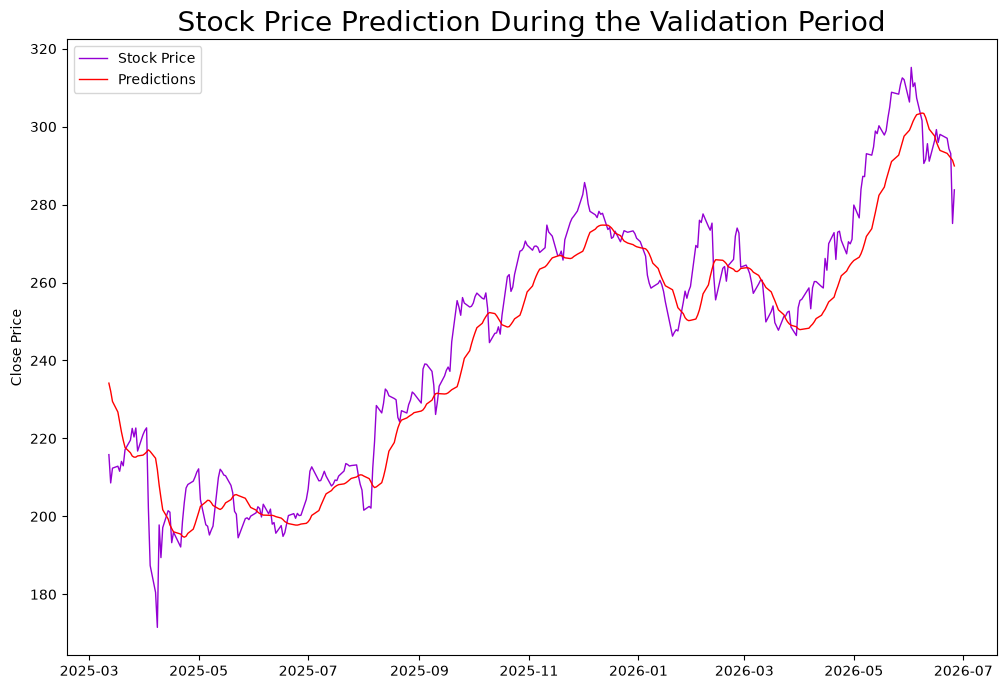

In [22]:
plt.figure(figsize=(12,8))
plt.title("Stock Price Prediction During the Validation Period", fontsize = 20)
plt.ylabel("Close Price")
plt.plot(ValidationSet["Close"],linewidth=1,color = "Darkviolet")
plt.plot(ValidationSet["Predictions"],linewidth=1,color = "Red")
plt.legend(["Stock Price","Predictions"])

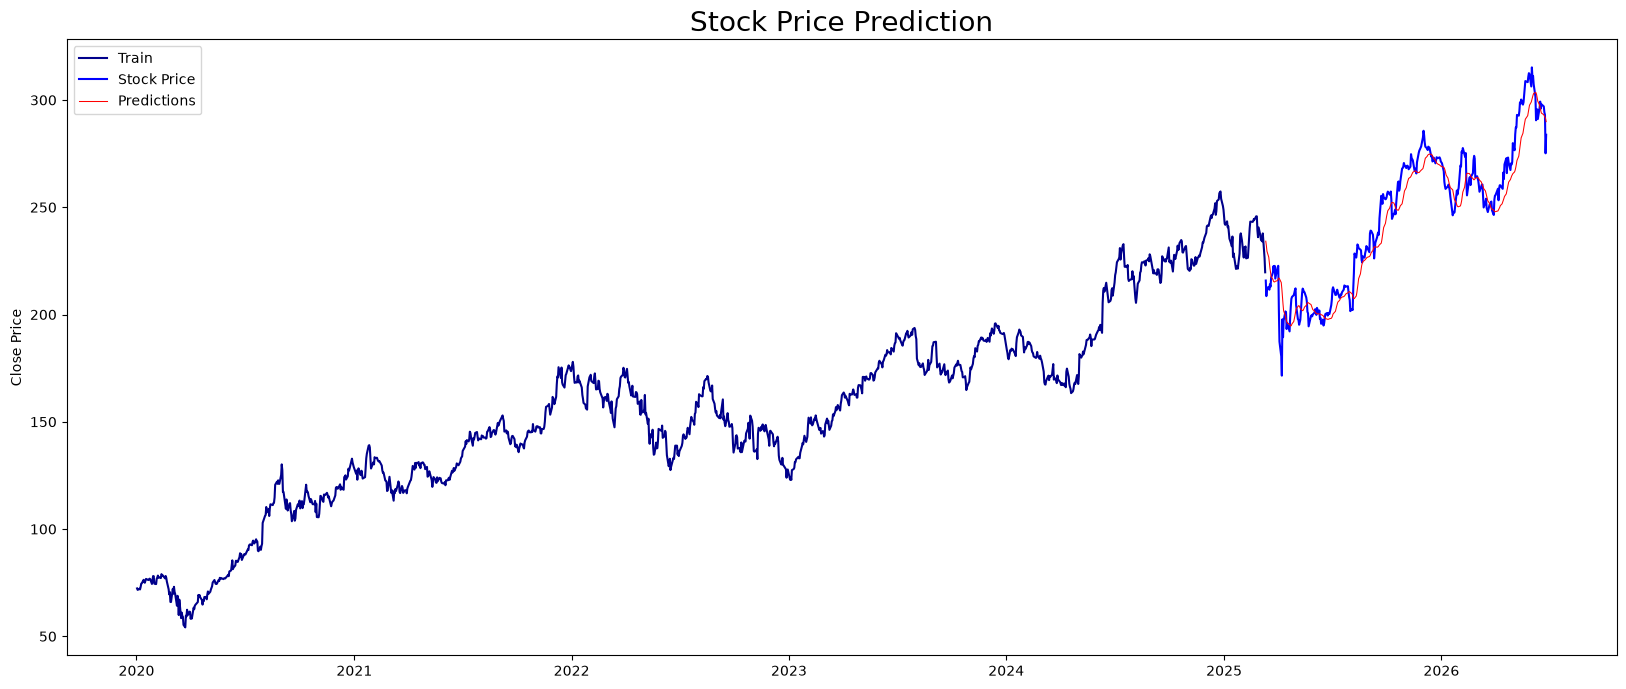

In [23]:
plt.figure(figsize=(20,8))
plt.title("Stock Price Prediction", fontsize=20)
plt.ylabel("Close Price" )
plt.plot(TrainingSet["Close"], color = "Darkblue")
plt.plot(ValidationSet["Close"],color = "Blue")
plt.plot(ValidationSet["Predictions"],linewidth=0.75,color = "Red")
plt.legend(["Train","Stock Price","Predictions"])